/tmp/ipykernel_612921/447940201.py:118: RuntimeWarning: invalid value encountered in cast
  heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)


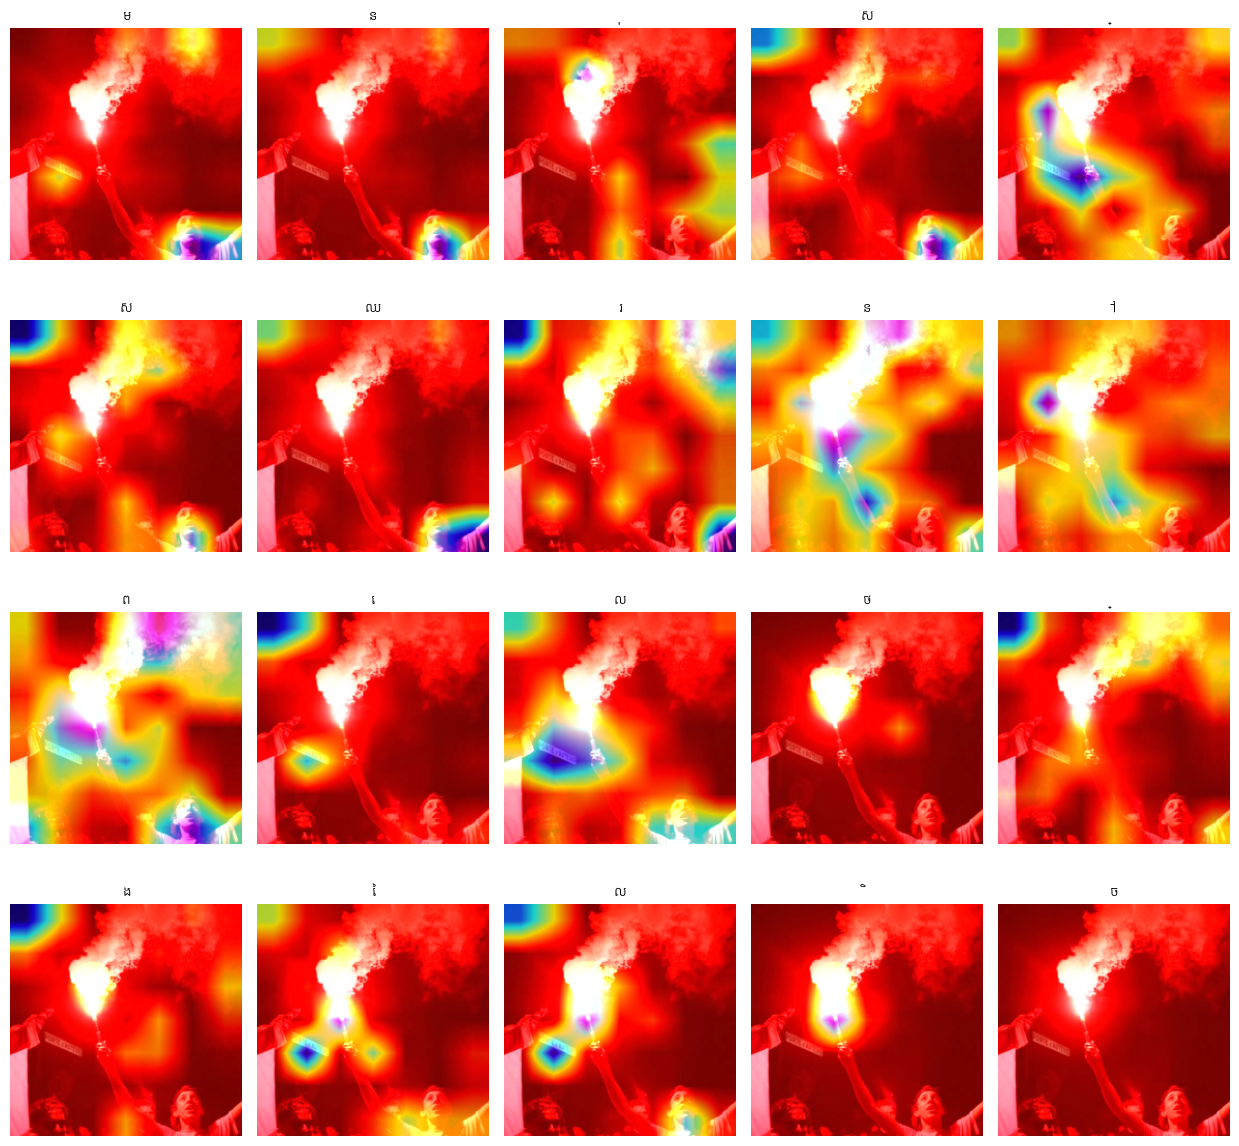

Generated Caption: មនុស្សឈរនៅពេលថ្ងៃលិច


In [5]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math



# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c
    
     # ✅ Add this for summary/training compatibility
    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        h = self.init_h(encoder_out.mean(dim=1))
        c = self.init_c(encoder_out.mean(dim=1))

        outputs = []
        for t in range(seq_len):
            output, h, c = self.forward_step(encoder_out, captions[:, t], h, c)
            outputs.append(output.unsqueeze(1))  # (B, 1, vocab_size)

        return torch.cat(outputs, dim=1)  # (B, seq_len, vocab_size)

# GradCAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze()
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()

def overlay_heatmap(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    return np.clip(heatmap * 0.8 + img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v1.pth'))
decoder.load_state_dict(torch.load('decoder_final_v1.pth'))
encoder.eval()
decoder.eval()
gradcam = GradCAM(encoder.resnet[-1], encoder.resnet[-1][-1])

# Generate caption and visualize Grad-CAM
def generate_caption_with_gradcam(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)

    tensor_img.requires_grad = True
    encoder_out = encoder(tensor_img)
    h = decoder.init_h(encoder_out.mean(dim=1))
    c = decoder.init_c(encoder_out.mean(dim=1))

    seq = [word2idx['<START>']]
    tokens, heatmaps = [], []

    for _ in range(40):
        last_token = torch.tensor([seq[-1]]).to(device)
        output, h, c = decoder.forward_step(encoder_out, last_token, h, c)
        idx = output.argmax(1).item()
        if idx in [word2idx['<END>'], word2idx['<PAD>']]:
            break
        seq.append(idx)
        tokens.append(idx2word[str(idx)])

        # Backward pass for Grad-CAM
        encoder.zero_grad()
        decoder.zero_grad()
        output[0, idx].backward(retain_graph=True)
        cam = gradcam.generate_cam()
        heatmaps.append(overlay_heatmap(img_for_display, cam))
        
    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    # Define layout
    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    # Flatten axes if needed
    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(heatmaps[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/FB_IMG_1748771868473.jpg'

# Run
caption = generate_caption_with_gradcam(image_path)
print("Generated Caption:", caption)


In [12]:
print("✅ Encoder Type:", type(encoder)) 
print("✅ Number of Parameters in Encoder:", sum(p.numel() for p in encoder.parameters()))
print("✅ Number of Trainable Parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))

✅ Encoder Type: <class '__main__.EncoderCNN'>
✅ Number of Parameters in Encoder: 23508032
✅ Number of Trainable Parameters: 14964736


In [11]:
print("✅ Decoder Type:", type(decoder))
print("✅ Number of Parameters in Decoder:", sum(p.numel() for p in decoder.parameters()))
print("✅ Number of Trainable Parameters:", sum(p.numel() for p in decoder.parameters() if p.requires_grad))


✅ Decoder Type: <class '__main__.DecoderRNN'>
✅ Number of Parameters in Decoder: 8579143
✅ Number of Trainable Parameters: 8579143


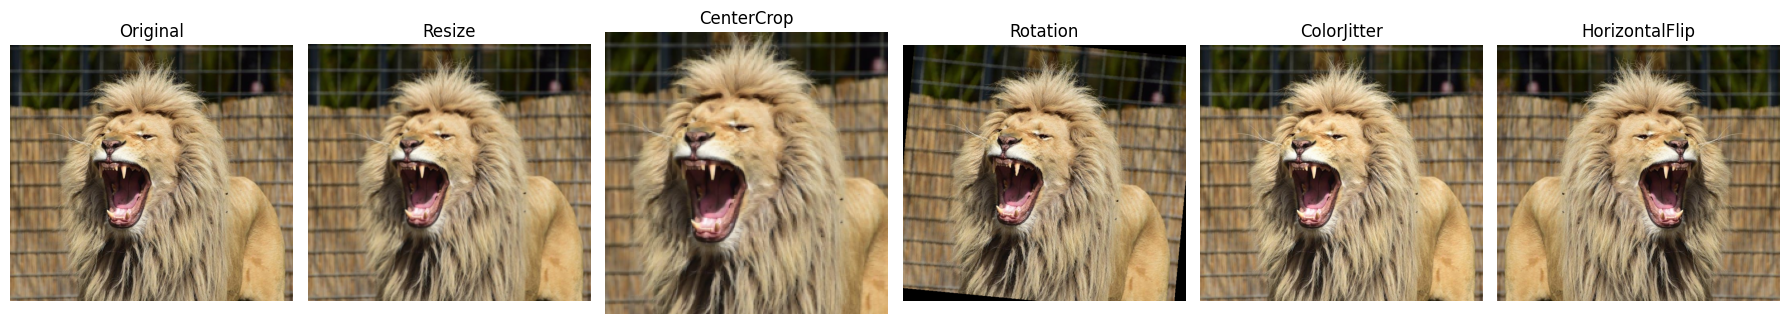

In [38]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import random
import torch

# Load the original image
img_path = '/home/vitoupro/code/image_captioning/data/pexels_109.jpg'
original_img = Image.open(img_path).convert("RGB")

# Prepare individual transforms
resize = transforms.Resize(256)
center_crop = transforms.CenterCrop(224)
random_rotation = lambda img: TF.rotate(img, angle=random.uniform(-15, 15))
color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2)
horizontal_flip = lambda img: TF.hflip(img) if random.random() > 0.5 else img

# Apply each transform to a copy of the image
images = [
    ("Original", original_img),
    ("Resize", resize(original_img)),
    ("CenterCrop", center_crop(resize(original_img))),
    ("Rotation", random_rotation(original_img)),
    ("ColorJitter", color_jitter(original_img)),
    ("HorizontalFlip", horizontal_flip(original_img)),
]

# Plot all images
plt.figure(figsize=(18, 4))
for i, (name, img) in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    # Convert to numpy array if it's a tensor
    if isinstance(img, torch.Tensor):
        img = TF.to_pil_image(img)
    plt.imshow(img)
    plt.axis('off')
    plt.title(name)

plt.tight_layout()
plt.show()


In [7]:
from torchsummary import summary

# For EncoderCNN (input shape should be [3, 224, 224])
print("📦 EncoderCNN Summary")
summary(encoder.to(device), input_size=(3, 224, 224))

# For DecoderRNN — you must define dummy inputs manually due to custom forward logic
# Assuming encoder_out shape is (batch_size, 196, 2048)
print("\n📦 DecoderRNN Summary (partial):")
from torchinfo import summary as torchinfo_summary

dummy_encoder_out = torch.randn(1, 196, 2048).to(device)
dummy_caption = torch.randint(0, len(word2idx), (1, 10)).to(device)

# Only works if DecoderRNN’s forward() is callable directly
output= decoder(dummy_encoder_out, dummy_caption)
print(f"Decoder output shape: {output.shape}")

📦 EncoderCNN Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-

In [8]:
import torch
import torch.nn as nn
from torchinfo import summary

class DecoderWrapper(nn.Module):
    def __init__(self, decoder):
        super().__init__()
        self.decoder = decoder

    def forward(self, inputs):
        encoder_out, captions = inputs
        return self.decoder(encoder_out, captions)


In [ ]:
# Wrap the decoder
wrapped_decoder = DecoderWrapper(decoder).to(device)

# Define dummy inputs (batch_size=1, 196 patches, 2048 feature dim, sequence length=10)
dummy_encoder_out = torch.randn(1, 196, 2048).to(device)
dummy_captions = torch.randint(0, len(word2idx), (1, 10)).to(device)

# Use torchinfo.summary
summary(
    wrapped_decoder,
    input_data=((dummy_encoder_out, dummy_captions),),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3,
)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
DecoderWrapper                           [1, 196, 2048]            [1, 10, 70]               --                        True
├─DecoderRNN: 1-1                        [1, 196, 2048]            [1, 10, 70]               --                        True
│    └─Linear: 2-1                       [1, 2048]                 [1, 512]                  1,049,088                 True
│    └─Linear: 2-2                       [1, 2048]                 [1, 512]                  1,049,088                 True
│    └─Embedding: 2-3                    [1]                       [1, 256]                  17,920                    True
│    └─Dropout: 2-4                      [1, 256]                  [1, 256]                  --                        --
│    └─Attention: 2-5                    [1, 196, 2048]            [1, 2048]                 --                        True
│    